Stock Prices Prediction

# Task 2: Predict Future Stock Prices (Short-Term)

## Objective
Predict next-day stock closing price using historical stock data (OHLCV features).

## Dataset
Historical stock data fetched using yfinance (Apple Inc. - AAPL)

## Steps:
1. Load stock data
2. Preprocess dataset
3. Split into training and testing
4. Train Linear Regression and Random Forest models
5. Evaluate models
6. Visualize actual vs predicted prices
7. Insights & Conclusion

Importing Libraries

In [1]:
# Install yfinance to fetch stock data
!pip install yfinance

# Data manipulation
import pandas as pd
import numpy as np

# Stock data fetching
import yfinance as yf

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


Fetch Historical Stock Data

In [4]:
# Stock symbol and date range
stock_symbol = "AAPL"
start_date = "2022-01-01"
end_date = "2023-12-31"

# Fetch data automatically
data = yf.download(stock_symbol, start=start_date, end=end_date)

# Look at the first few rows
data.head()


/tmp/ipython-input-2864830239.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103668,178.955006,173.895967,174.013387,104487900
2022-01-04,175.843231,179.013699,175.275678,178.710355,99310400
2022-01-05,171.165863,176.303187,170.891874,175.755209,94537600
2022-01-06,168.308502,171.537680,167.956228,168.993476,96904000
2022-01-07,168.474854,170.402574,167.359321,169.179402,86709100


Preprocess Dataset

In [5]:
# Add column for next day's closing price
data['Next_Close'] = data['Close'].shift(-1)

# Remove the last row (it has no next day)
data = data[:-1]

# Select features to predict closing price
X = data[['Open', 'High', 'Low', 'Volume']]

# Target variable
y = data['Next_Close']


Split Into Training and Testing

In [6]:
# 80% data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Train the Models

In [8]:
#Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)


In [9]:
#Random Forest Regression
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


Check Model Accuracy

In [10]:
# Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# Print results
print("Linear Regression -> MAE:", round(mae_lr,2), "RMSE:", round(rmse_lr,2))
print("Random Forest -> MAE:", round(mae_rf,2), "RMSE:", round(rmse_rf,2))


Linear Regression -> MAE: 2.22 RMSE: 2.98
Random Forest -> MAE: 2.62 RMSE: 3.33


Plot Predictions

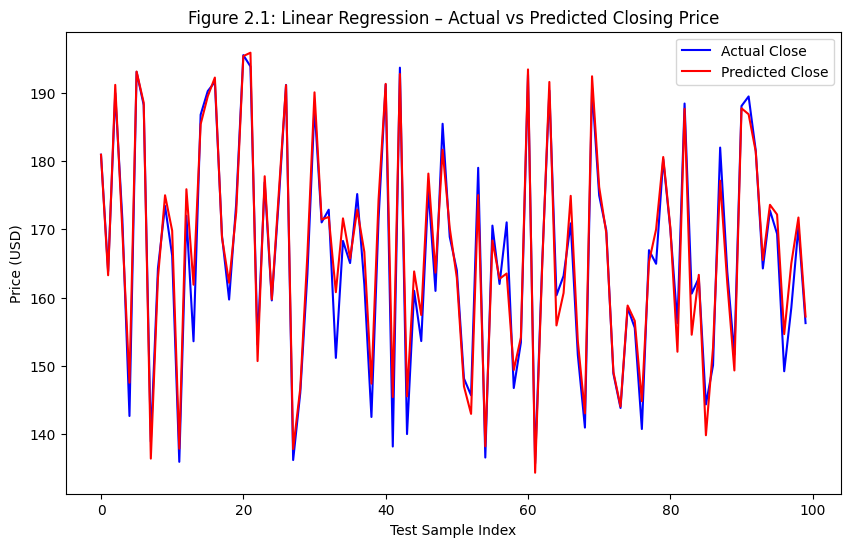

In [13]:
#Linear Regression
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label="Actual Close", color="blue")
plt.plot(y_pred_lr, label="Predicted Close", color="red")
plt.title("Figure 2.1: Linear Regression – Actual vs Predicted Closing Price")
plt.xlabel("Test Sample Index")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


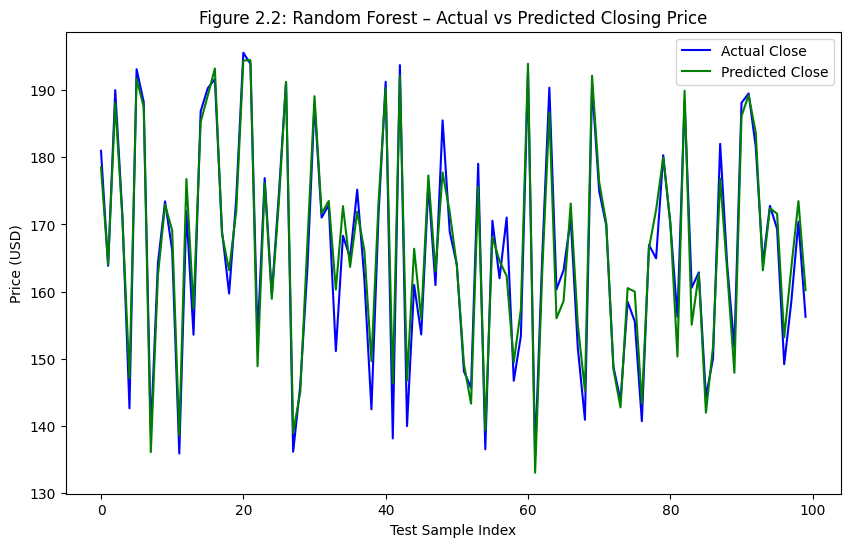

In [14]:
#Random Forest Regression
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label="Actual Close", color="blue")
plt.plot(y_pred_rf, label="Predicted Close", color="green")
plt.title("Figure 2.2: Random Forest – Actual vs Predicted Closing Price")
plt.xlabel("Test Sample Index")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


Insights / Conclusion

# Conclusion

- Linear Regression and Random Forest models predict next-day AAPL closing prices.
- Random Forest performs better (lower MAE and RMSE).
- Predicted prices closely follow actual prices → OHLCV features are useful.
- Future improvement: add technical indicators or advanced models like LSTM.
